<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #FFFFFF; max-width: 90%; overflow-x: auto; color: #000000;">

<img src="../resources/swdb_logo.jpg">


<h1 align="center">Workshop 2 Extended: Real Dynamic Routing Data</h1>
<h3 align="center">Summer Workshop on the Dynamic Brain</h3>
<h4 align="center">Thursday, August 27th, 2026</h4>
<h4 align="center">Day 4</h4>

---

***Authors:** Nick Steinmetz, Carrie Stine*

---

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## Applying the Analysis to Real Neural Recordings

In Workshop 2, we showed the pitfall in a simulation where we knew the ground truth.
Now we apply the same pipeline to a real session from the
**Dynamic Routing** dataset — where the neurons *might* encode things, and we
need the controls to tell us what is real.

### The Dynamic Routing task

Four stimulus types — vis1, vis2, sound1, sound2 — appear on every trial.
The session alternates between **visual** and **auditory context blocks**.
- Visual context: only vis1 triggers reward.
- Auditory context: only sound1 triggers reward.

The *same* stimulus can be a target or a non-target depending on context.
This context (visual vs auditory) alternates in blocks, just like the
+1/−1 blocks in our simulation.

### What we will test

1. **Test 1 (pupil analog):** Are neurons correlated with running speed?
   Running speed, like pupil diameter, has slow fluctuations.
2. **Test 2 (block decoding):** Can we decode the context block (vis vs aud)?

We will apply both the **naive analysis** and the **good controls** from Part 1.

</div>


# Part 1 - Real Data Setup

In [1]:
# standard imports
import sys
import os
from pathlib import Path

if '__vsc_ipynb_file__' in dir():
    nb_dir = Path(__vsc_ipynb_file__).parent
    os.chdir(nb_dir)
    sys.path.append(str(nb_dir.parent))  # adds code/ws2/ to path
else:
    sys.path.append("/code/Workshop-2_NonsenseCorrelations")
    
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch
from matplotlib import colors  
from scipy import stats
from scipy.ndimage import gaussian_filter1d
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import KFold

# Preprocessing utilities (kept for downstream feature scaling)
# from sklearn.preprocessing import StandardScaler  # Standardizes features (zero mean, unit variance)


# Progress bar utility for long loops
from tqdm import tqdm  # Displays a smart progress bar during loops

import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='hdmf_zarr')

# Show all columns when inspecting wide DataFrames
pd.set_option('display.max_columns', None)  # Ensures all columns are shown when printing DataFrames

# setup code for importing helper functions
import importlib
import workshop2_utils
importlib.reload(workshop2_utils) # automatically reloads helper functions if they are changed while kernel is running




# Global figure settings
plt.rcParams['font.family']       = 'sans-serif'
plt.rcParams['font.sans-serif']   = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['pdf.fonttype']      = 42
plt.rcParams['ps.fonttype']       = 42


In [2]:
import platform
import pynwb

root = Path("/root/capsule/data/dynamicrouting_datacube")

example_session_ids = [
                        "759434_2025-02-04", "713655_2024-08-09", "743199_2024-12-05", 
                        "712815_2024-05-22", "742903_2024-10-23", "664851_2023-11-16", 
                        "741137_2024-10-10", "662892_2023-08-24", "714748_2024-06-24",
                        "667252_2023-09-28", "715710_2024-07-16", "708016_2024-04-29"
                    ]


session_id = example_session_ids[11]

# loop through the directories to find the NWB file for the specific session 
for d in root.iterdir():
    nwb_path = d / f"{session_id}.nwb.zarr"
    if nwb_path.exists():
        print(nwb_path)
        break

/root/capsule/data/dynamicrouting_datacube/ecephys_708016_2024-04-29_12-59-12_nwb_2026-08-04_15-02-46/708016_2024-04-29.nwb.zarr


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

### Create the session object and trials table

We will now access the session data using `pynwb`, and create a pandas dataframe `trials` that contains all trial information.

</div>


In [3]:
session = pynwb.read_nwb(nwb_path)

# Materialize trial table as a DataFrame-like object for analysis
trials = session.trials.to_dataframe()

<div style="border-left: 3px solid #07bc0a; padding: 1px; padding-left: 10px; background: #DFF0D8;  max-width: 90%; overflow-x: auto; color: #000000;">

### Exercise: Getting oriented with the real data

Before jumping into analysis, let's take a moment to look at what is available in the session data.

1. **How many trials does the session have?** Print `len(trials)`.
<br>

2. **What columns does the trials table have?** Print `trials.columns.tolist()`.
<br>

3. **How many columns are in the trials table?** Print `len(trials.columns.tolist())`.
<br>


</div>


In [4]:
# YOUR CODE HERE
# 1. How many trials does the session have?
num_trials = len(trials)
print(f'1. Session has {num_trials} trials')
print()

# 2. What columns does the trials table have?
print('2. Trial columns:', trials.columns.tolist())
print()

# 3. How many columns are in the trials table?
print(f'3. Trials table has {len(trials.columns.tolist())} columns')
print()

1. Session has 533 trials

2. Trial columns: ['start_time', 'stop_time', 'quiescent_start_time', 'quiescent_stop_time', 'stim_start_time', 'stim_stop_time', 'response_window_start_time', 'response_window_stop_time', 'task_control_response_time', 'response_time', 'reward_time', 'post_response_window_start_time', 'post_response_window_stop_time', 'stim_name', 'grating_phase', 'block_index', 'rewarded_modality', 'trial_index', 'trial_index_in_block', 'repeat_index', 'is_response', 'is_correct', 'is_incorrect', 'is_hit', 'is_false_alarm', 'is_correct_reject', 'is_miss', 'is_go', 'is_nogo', 'is_rewarded', 'is_noncontingent_reward', 'is_contingent_reward', 'is_reward_scheduled', 'is_instruction', 'is_aud_stim', 'is_vis_stim', 'is_catch', 'is_target', 'is_aud_target', 'is_vis_target', 'is_nontarget', 'is_aud_nontarget', 'is_vis_nontarget', 'is_vis_rewarded', 'is_aud_rewarded', 'is_block_switch', 'is_repeat', 'is_opto', 'is_task_control_correct']

3. Trials table has 49 columns



<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; max-width: 90%; overflow-x: auto; color: #000000;">

### Find categorical columns in the trials table

The trials table contains many columns that store continuous measurements, which can take on a large range of values. We want to find the *categorical* columns that **label which task context was active on each trial**. To do so, we scan for columns with fewer than 5 unique values. Low-cardinality columns are likely categorical condition labels rather than continuous measurements.

</div>


In [5]:
# Find context column
for col in trials.columns:
    unique_vals = trials[col].dropna().unique()
    if len(unique_vals) < 5:
        print(f'  {col}: {unique_vals}')

  grating_phase: [0.  0.5]
  rewarded_modality: <StringArray>
['aud', 'vis']
Length: 2, dtype: str
  repeat_index: [0.]
  is_response: [ True False]
  is_correct: [ True False]
  is_incorrect: [False  True]
  is_hit: [ True False]
  is_false_alarm: [False  True]
  is_correct_reject: [False  True]
  is_miss: [False  True]
  is_go: [ True False]
  is_nogo: [False  True]
  is_rewarded: [ True False]
  is_noncontingent_reward: [False  True]
  is_contingent_reward: [ True False]
  is_reward_scheduled: [ True False]
  is_instruction: [ True False]
  is_aud_stim: [ True False]
  is_vis_stim: [False  True]
  is_catch: [False  True]
  is_target: [ True False]
  is_aud_target: [ True False]
  is_vis_target: [False  True]
  is_nontarget: [False  True]
  is_aud_nontarget: [False  True]
  is_vis_nontarget: [False  True]
  is_vis_rewarded: [False  True]
  is_aud_rewarded: [ True False]
  is_block_switch: [False  True]
  is_repeat: [False]
  is_opto: [False]
  is_task_control_correct: [False  True]


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; max-width: 90%; overflow-x: auto; color: #000000;">

### QC the units table

Just as the `trials` table contains information about each trial, the `units` table contains information about each unit. We will only keep units that pass a few quality metrics:

1. **MAX_ISI**: ISI violations ratio, represents the fraction of spikes too close together to be a single neuron. *Too high means either noise or 2 neurons are merged.*
2. **MAX_AMP_C**: amplitude cutoff, represents the fraction of spikes for a neuron that fall below the spike-sorting algorithm's detection threshold.
3. **MIN_PRES**:presence ratio, represents the fraction of the session in which the neuron is observed.

> *Note: This cell takes ~ 1 minute to run.*

</div>


In [6]:
# Convert unit metadata to a pandas table for quality filtering
units_table = session.units.to_dataframe()



In [7]:
# QC thresholds
MAX_ISI_VIOLATIONS_RATIO = 0.5    # lower is better
MAX_AMPLITUDE_CUTOFF = 0.1        # lower is better
MIN_PRESENCE_RATIO = 0.95         # higher is better

# Keep only units that pass all quality-control criteria
good_units_dr = units_table[
    (units_table.isi_violations_ratio < MAX_ISI_VIOLATIONS_RATIO) &
    (units_table.amplitude_cutoff < MAX_AMPLITUDE_CUTOFF) &
    (units_table.presence_ratio > MIN_PRESENCE_RATIO)
]

print(f'{len(good_units_dr)} units after QC')
print()
print('Brain areas with good units:')
print(good_units_dr.structure.value_counts().head(10))

900 units after QC

Brain areas with good units:
structure
MOs     167
CA3     120
SSp     113
MOp      82
ProS     68
MGv      64
AId      56
GU       49
LGd      27
DG       25
Name: count, dtype: int64


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; max-width: 90%; overflow-x: auto; color: #000000;">

### Select two example neurons for correlation testing

We've pre-selected 2 neurons to test in the analysis pipeline. Are either of them correlated with pupil diameter? Can either be used to decode the context (audio vs visual) block?

First, let's **build a matrix of per-trial spike counts** for each unit in the 0.5 s window before each stimulus presentation.

</div>


In [8]:
# Helper function: builds a per-trial peri-stimulus time histogram (PSTH) matrix
def make_psth(spike_times, stim_times, pre_window=0.5, post_window=1.0, bin_size=0.05):

    # Convert inputs to numpy arrays
    spike_times = np.array(spike_times)
    stim_times = np.array(stim_times)
    
    # Create time bins relative to each stimulus event
    bins = np.arange(-pre_window, post_window + bin_size, bin_size)
    bin_centers = bins[:-1] + bin_size/2
    
    # Initialize array to store spike counts for each trial
    all_counts = np.zeros((len(stim_times), len(bins)-1))
    
    # Count spikes in each bin for each trial
    for i, stim_time in enumerate(stim_times):
        # Find spikes within the window for this trial
        mask = ((spike_times >= stim_time - pre_window) & 
                (spike_times < stim_time + post_window))
        trial_spikes = spike_times[mask] - stim_time
        
        # Count spikes in each bin
        counts, _ = np.histogram(trial_spikes, bins=bins)
        all_counts[i, :] = counts
    
    # Convert counts to firing rate (spikes/second)
    firing_rates = all_counts / bin_size
    
    return firing_rates, bin_centers

In [9]:
unit1_id = '708016_2024-04-29_A-16'
unit2_id = '708016_2024-04-29_A-22'

# Use stimulus onset as trial-alignment event
stim_times = trials.stim_start_time

# Load the first unit
unit1 = good_units_dr[good_units_dr.unit_id == unit1_id]

unit1_spike_counts = []
# Build per-unit, per-trial spike counts in a 0.5 s pre-stimulus window
unit1_spike_counts, bin_centers = make_psth(unit1['spike_times'].values[0], stim_times, \
    pre_window=0.5, post_window=0, bin_size=0.5)

# Repeat the process for the second unit
unit2 = good_units_dr[good_units_dr.unit_id == unit2_id]

unit2_spike_counts = []
# Build per-unit, per-trial spike counts in a 0.5 s pre-stimulus window
unit2_spike_counts, bin_centers = make_psth(unit2['spike_times'].values[0], stim_times, \
    pre_window=0.5, post_window=0, bin_size=0.5)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

### Visualize the neuron activity - raster plot
A **raster plot** shows every spike as a tick mark, with neurons on the y-axis
and time on the x-axis. Here we show the first 90 s of the task for our two selected units.

</div>


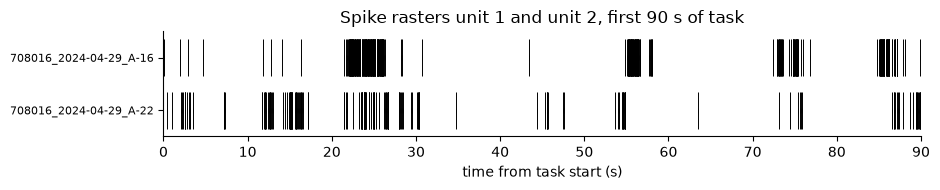

In [10]:
N_SHOW = 2
T_START = stim_times.iloc[0]
T_SHOW = 90

spike_times_list = [
    np.asarray(unit1['spike_times'].values[0]),
    np.asarray(unit2['spike_times'].values[0])
]
unit_labels = [unit1_id, unit2_id]

fig, ax = plt.subplots(figsize=(9.5, 2))
ax.eventplot([st[(st >= T_START) & (st <= T_START + T_SHOW)] - T_START
              for st in spike_times_list],
             colors='k', linewidths=0.7,
             lineoffsets=np.arange(N_SHOW), linelengths=0.7)
ax.set_xlim(0, T_SHOW)
ax.set_ylim(N_SHOW - 0.5, -0.5)
ax.set_yticks(np.arange(N_SHOW))
ax.set_yticklabels(unit_labels, fontsize=8)
ax.set_xlabel('time from task start (s)')
ax.eventplot([st[(st >= T_START) & (st <= T_START + T_SHOW)] - T_START
              for st in spike_times_list],
             colors='k', linewidths=0.4, linelengths=0.1,
             lineoffsets=np.arange(N_SHOW))
ax.set_title(f'Spike rasters unit 1 and unit 2, first {T_SHOW} s of task')
plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; max-width: 90%; overflow-x: auto; color: #000000;">

### Extract the pupil trace

Now let's pull out the pupil trace for this session. We will extract the trial-wise average of the pupil area in the 1.5 s window before stimulus onset.

</div>


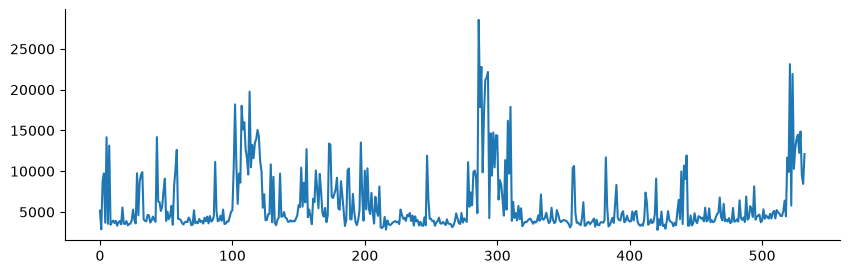

In [11]:
# Summarize continuous signals into one value per trial window
def get_trialwise_values(x, timestamps, start, stop):
    """
    Extracts trial-wise summary statistics of different behaviors (mean or median) from a time-aligned signal.

    Parameters:
    - x : array-like
        Signal values (e.g., neural data or behavioral measurements).
    - timestamps : array-like
        Time points corresponding to each value in x.
    - start : array-like
        Start times for each trial.
    - stop : array-like
        Stop times for each trial.

    Returns:
    - values : list
        List of mean or median values for each trial window.
    """
    return np.array([np.nanmean(x[np.logical_and(s1 <= timestamps, timestamps <= s2)]) 
            for s1, s2 in zip(start, stop)])


# Define a pre-stimulus window for each trial
trial_start = trials.stim_start_time.values - 1.5 
trial_stop = trials.stim_start_time.values

# Load eye-tracking pupil trace from the behavior processing module
pupil_data = session.processing['behavior']['eye_tracking']
pupil_timestamps = pupil_data.timestamps[:]
pupil_area = pupil_data.pupil_area[:]

# Fill missing samples, then compute one trial-wise average per window
pupil_area = pd.Series(pupil_area).interpolate(limit_direction='both').to_numpy() 
pupil_area = get_trialwise_values(pupil_area, pupil_timestamps, trial_start, trial_stop)

# Visualize trial-by-trial pupil area estimates
fig, ax = plt.subplots(figsize = (10, 3))
ax.plot(pupil_area)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; max-width: 90%; overflow-x: auto; color: #000000;">

### Plot the unit activity, pupil trace, and block identity on the same axes

Let's visualize our data before going further. **What predictions can we make based on this visualization?**

</div>


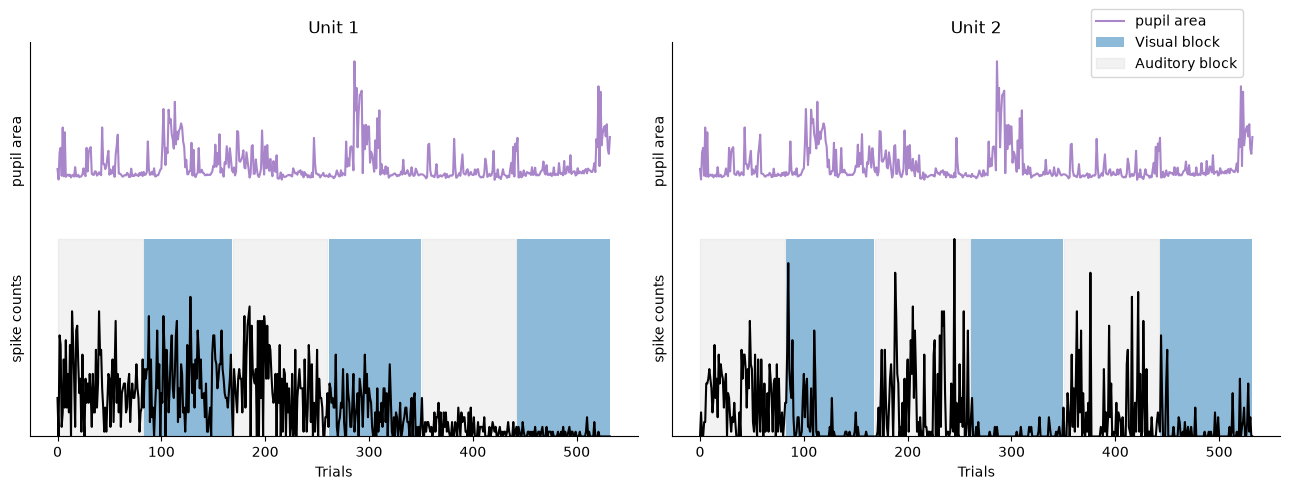

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

vis_block = trials.is_vis_rewarded
y1 = unit1_spike_counts.reshape(-1)
y2 = unit2_spike_counts.reshape(-1)
max_y = np.max([np.max(y1), np.max(y2)])

# Normalize pupil to sit above the spike data
pupil_norm = (pupil_area - np.nanmin(pupil_area)) / (np.nanmax(pupil_area) - np.nanmin(pupil_area))
pupil_plot = max_y * 1.3 + pupil_norm * max_y * 0.6  # offset + scale

for ax, y, title in zip(axes, [y1, y2], ['Unit 1', 'Unit 2']):
    ax.plot(y, color='k')
    ax.plot(pupil_plot, color='tab:purple', alpha=0.8, lw=1.5, label='pupil area')
    ax.fill_between(vis_block.index, 0, max_y, where=vis_block == 1, alpha=0.5, label='Visual block')
    ax.fill_between(vis_block.index, 0, max_y, where=vis_block == 0, alpha=0.2, color='silver', label='Auditory block')
    ax.set_xlabel('Trials')
    ax.set_ylabel('spike counts                      pupil area')
    ax.set_title(title)
    ax.set_ylim(0, max_y * 2)
    ax.set_yticks([])  # hide y ticks since the two scales are mixed

axes[1].legend(bbox_to_anchor=(0.95, 1.1))
plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

### Select an area and compute trial-by-trial firing rates

We will use **MOs** (secondary motor cortex) — an area that we might expect
to be involved in the task, but where slow fluctuations may dominate apparent
correlations.

For each trial, we count spikes from trial `start_time` to `stop_time` and
divide by duration to get a firing rate.

</div>


In [ ]:
# Select the brain area
AREA      = 'MOs'
area_units = good_units_dr[good_units_dr.structure == AREA]
print(f'{len(area_units)} good units in {AREA}')

# Compute trial-by-trial firing rates  shape: (n_neurons, n_trials_dr)
t_stops = trials.stim_start_time.values
t_starts  = t_stops - 1.5
dur      = t_stops - t_starts     # trial durations (s)

n_neurons_dr = len(area_units)
n_trials_dr  = len(trials)
fr_dr = np.zeros((n_neurons_dr, n_trials_dr))

for nn, (_, row) in enumerate(area_units.iterrows()):
    spk = np.asarray(row.spike_times)
    for tt, (ts, te) in enumerate(zip(t_starts, t_stops)):
        fr_dr[nn, tt] = np.sum((spk >= ts) & (spk < te)) / dur[tt]

frz_dr = ((fr_dr - fr_dr.mean(axis=1, keepdims=True))
          / (fr_dr.std(axis=1, keepdims=True) + 1e-9))

print(f'Firing rate matrix shape: {fr_dr.shape}  (neurons x trials)')
print(f'Mean firing rate: {fr_dr.mean():.2f} spikes/s')


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

### Visualize the neuron activity - raster plot
A **raster plot** shows every spike as a tick mark, with neurons on the y-axis
and time on the x-axis. Here we show the first 15 min of the task for 30 MOs neurons.

</div>


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

### Visualize the neuron activity - z-scored firing matrix
Lets visualize the raw and z-scored firing rate matrix to see what neuron activity looks like across all trials.

</div>


In [ ]:
# import the show_matrix helper function
from workshop2_utils import show_matrix

# setup the plotting area
fig, axes = plt.subplots(2, 1, figsize=(9.5, 6), sharex=True)

# plot the raw firing rate matrix on the first subplot
show_matrix(axes[0], fr_dr, 'magma', 0, np.percentile(fr_dr, 99.5),
            'Spike counts binned by trial', 'firing rate (spikes/s)')

# plot the z-scored firing rate matrix on the second subplot
show_matrix(axes[1], frz_dr, 'RdBu_r', -3, 3,
            'Same matrix, z-scored per neuron', 'z-score')
axes[1].set_xlabel('trial')
plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

### Locate a behavioral measurement that we can test for correlations with neural activity

Within this data, we want to locate a **slow behavioral signal** that we can test for spurious correlations with.

The code below explores the NWB file structure to find different types of behavior signals that were recorded.

</div>


In [ ]:
# Explore what behavioral time series are available
print('Processing modules:', list(session.processing.keys()))
for mod_name, mod in session.processing.items():
    print(f'  {mod_name}: {list(mod.data_interfaces.keys())}')
print()
print('Acquisition keys:', list(session.acquisition.keys()))


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

### Extract running speed per trial

Running speed is a good real-data analog of the simulated pupil trace that we can explore further. Based on our above exploration, it looks like running speed can be found at `processing["behavior"]["running_speed"]`.

Let's extract the running trace and average the instantaneous speed within each trial window.

</div>


In [ ]:
# Retrieve running speed
rs               = session.processing["behavior"]["running_speed"]
running_speed_dr = rs.data[:]
running_times_dr = rs.timestamps[:]

# Average within each trial window (# take absolute value, signed wheel velocity can be negative)
running_trial_dr = np.array([
    np.mean(np.abs(running_speed_dr[(running_times_dr >= ts) &  
                                    (running_times_dr <  te)]))
    for ts, te in zip(t_starts, t_stops)
])

running_z_dr = ((running_trial_dr - running_trial_dr.mean())
                / (running_trial_dr.std() + 1e-9))

print(f'Running speed per trial: mean={running_trial_dr.mean():.2f}, std={running_trial_dr.std():.2f}')

fig, ax = plt.subplots(figsize=(9.5, 2))
ax.plot(running_trial_dr, color='tab:green', lw=1.0)
ax.set_xlabel('trial'); ax.set_ylabel('running speed (cm/s)')
ax.set_title(f'Running speed across {n_trials_dr} trials')
plt.tight_layout(); plt.show()

In [ ]:
block_switches = np.where(trials['is_block_switch'].values)[0]
block_id = (trials['rewarded_modality'].values == 'vis').astype(float)

traces = [
    (fr_dr.mean(axis=0),                    'k',          'mean firing rate\n(spikes/s)', False),
    (running_trial_dr,                      'tab:green',  'running speed\n(cm/s)',        False),
    (trials['is_hit'].values.astype(float), 'tab:orange', 'hit rate\n(raw)',              False),
    (block_id,                              'tab:blue',   'block id\n(1=vis, 0=aud)',     True),
]

fig, axes = plt.subplots(len(traces), 1, figsize=(11, 7), sharex=True)

for ax, (data, color, ylabel, is_block) in zip(axes, traces):
    if is_block:
        ax.fill_between(np.arange(len(data)), data, step='post', color=color, alpha=0.4)
        ax.plot(data, color=color, lw=0.8, drawstyle='steps-post')
        ax.set_ylim(-0.1, 1.1)
        ax.set_yticks([0, 1]); ax.set_yticklabels(['aud', 'vis'])
    else:
        ax.plot(data, color=color, lw=1.2)
    for bs in block_switches:
        ax.axvline(bs, color='0.7', lw=0.8, ls='--', zorder=0)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xlim(0, n_trials_dr)

axes[0].set_title(f'{AREA}: behavioral signals across trials')
axes[-1].set_xlabel('trial')
plt.tight_layout()
plt.show()

# Part 2 - Neuron Correlation with Running Speed

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## Are MOs neurons correlated with running speed?

We computed the mean running speed within each trial window and z-scored it. We will now correlate the running speed with each neuron's trial-by-trial firing rate using the same analysis pipeline applied to the simulated data in Workshop 2.

In [ ]:
# import helper functions
from workshop2_utils import corr_rows, crit_r, hist_by_significance

In [ ]:
# Compute correlations with running speed using the same pipeline as Part 1
r_dr   = corr_rows(fr_dr, running_trial_dr)
r_crit_dr = crit_r(n_trials_dr)

# Compute parametric p-values
res_dr = [stats.pearsonr(fr_dr[i], running_trial_dr) for i in range(n_neurons_dr)]
p_dr   = np.array([x.pvalue for x in res_dr])
n_sig_dr = np.sum(p_dr < 0.05)

print(f'n = {n_trials_dr} trials  →  any |r| > {r_crit_dr:.3f} gives p < 0.05')
print(f'{n_sig_dr} / {n_neurons_dr} neurons significant (p < 0.05)')
print(f'Expected by chance: {0.05 * n_neurons_dr:.1f} / {n_neurons_dr}')
print(f'Median |r| = {np.median(np.abs(r_dr)):.3f}, max |r| = {np.max(np.abs(r_dr)):.3f}')

_edges_dr = np.arange(0, 0.8 + r_crit_dr, r_crit_dr)
R_BINS_DR = np.concatenate([-_edges_dr[1:][::-1], _edges_dr])

fig, ax = plt.subplots(figsize=(6, 3.2))
hist_by_significance(ax, r_dr, 
    f'Correlation with running speed',
    R_BINS_DR, r_crit_dr)
plt.tight_layout()
plt.show()


<div style="border-left: 3px solid #07bc0a; padding: 1px; padding-left: 10px; background: #DFF0D8;  max-width: 90%; overflow-x: auto; color: #000000;">

### Exercise: How many neurons appear correlated with running speed?

1. **How many neuron's were found to be significantly correlated with running speed?** Print `n_sig_dr`. 

2. **How does this number compare to the `~5%` you'd expect by chance?**


</div>


In [ ]:
# YOUR CODE HERE
# 1. How many MOs neurons were significantly correlated with running speed:
print(f'{n_sig_dr}/{n_neurons_dr} significant')

# 2. How does that number compare to the ~5% expected by chance:
print(f'{0.05*n_neurons_dr:.0f}/{n_neurons_dr} expected by chance')

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## Control: circular shift

Let's apply the circular shift control to our neuronal signal to see what result we get. 

In [ ]:
N_SHIFT_DR    = 200
shift_dr      = np.random.default_rng(42).integers(1, n_trials_dr, N_SHIFT_DR)

r_circ_dr = np.array([corr_rows(np.roll(fr_dr, s, axis=1), running_trial_dr)
                       for s in shift_dr])
p_circ_dr     = (np.sum(np.abs(r_circ_dr) >= np.abs(r_dr), axis=0) + 1) / (N_SHIFT_DR + 1)
n_sig_circ_dr = np.sum(p_circ_dr < 0.05)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(r_circ_dr.ravel(), bins=R_BINS_DR, density=True, color='0.6',
             label='circular-shift null')
axes[0].hist(r_dr, bins=R_BINS_DR, density=True, color='tab:blue', alpha=0.6,
             label='real data')
axes[0].set_xlabel("correlation with running speed (Pearson's r)")
axes[0].set_ylabel('density')
axes[0].set_title('Real DR data: circular-shift null vs real correlations')
axes[0].legend(frameon=False, fontsize=8)

axes[1].hist(p_circ_dr, bins=np.linspace(0, 1, 21), color='0.6')
axes[1].axvline(0.05, color='tab:red', lw=1.2, ls='--', label='p = 0.05')
axes[1].set_xlabel('p-value vs circular-shift null')
axes[1].set_ylabel('neurons')
axes[1].set_title(f'{n_sig_circ_dr}/{n_neurons_dr} neurons survive the shift test')
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

print(f'Parametric p < 0.05:          {n_sig_dr:3d} / {n_neurons_dr}')
print(f'Circular-shift null p < 0.05: {n_sig_circ_dr:3d} / {n_neurons_dr}')


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

## Did the same neurons survive both tests?


In [ ]:
sig_param = p_dr < 0.05
sig_circ  = p_circ_dr < 0.05
print(f'Both tests agree significant: {(sig_param & sig_circ).sum()}')
print(f'Parametric only:              {(sig_param & ~sig_circ).sum()}')
print(f'Circular shift only:          {(~sig_param & sig_circ).sum()}')
print(f'Both agree not significant:   {(~sig_param & ~sig_circ).sum()}')

<div style="border-left: 3px solid #f0b429; padding: 1px; padding-left: 10px; background: #FFF9C4;  max-width: 90%; overflow-x: auto; color: #000000;">

### What does this result indicate?



<details>
<summary><b>Answer:</b></summary>

   In a real recording of MOs neurons (126 neurons, 548 trials), we correlated each neuron's trial-by-trial firing rate with running speed. The parametric test found **74/126 neurons** (59%) significant. 
   
   Applying the circular shift null, which **preserves the slow temporal structure** of both signals while **breaking their trial-by-trial alignment**, reduced this to 42/126 (33%). All 42 neurons flagged by the circular shift *were also flagged* by the parametric test. 
   
   
   The 32 neurons unique to the parametric test have correlations that could be explained by slow co-fluctuation, since the circular shift null could not distinguish them from chance. Whether they have any genuine trial-by-trial coupling with running speed remains unresolved.

</details>

<br>

</div>

# Part 3 - Decoding the Context Block

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;  max-width: 90%; overflow-x: auto; color: #000000;">

We now **decode the visual vs auditory context block** from MOs population activity. This is directly analogous to the block decoding analysis in Workshop 2: the context label (visual or auditory) switches every ~80 trials, just like the +1/-1 block variable in our simulation.

First we will reconstruct the block IDs.

</div>


In [ ]:
# Get block labels: visual context = +1, auditory context = -1
CONTEXT_COL = 'rewarded_modality'    
context_raw = trials[CONTEXT_COL].values
context_vals = np.where(context_raw == 'vis', 1, -1).astype(float)

# Drop trials with NaN context
valid        = np.array([v is not None and str(v) not in ('nan', 'None', '')
                         for v in context_raw])
X_dr         = fr_dr[:, valid].T
y_dr         = context_vals[valid]


# Reconstruct block IDs from the context signal 
# (alternatively: block_ids_dr = trials['block_index'].values[valid])
block_ids_dr = np.zeros(len(y_dr), dtype=int)
b = 0
for i in range(1, len(y_dr)):
    if y_dr[i] != y_dr[i - 1]:
        b += 1
    block_ids_dr[i] = b

print(f'{valid.sum()} trials with known context ({len(np.unique(block_ids_dr))} blocks)')
print(f'Context distribution: {np.mean(y_dr==1)*100:.0f}% visual, '
      f'{np.mean(y_dr==-1)*100:.0f}% auditory')


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; max-width: 90%; overflow-x: auto; color: #000000;">

## Decoding visual vs auditory context block

Now we will try to decode the **visual vs auditory context block** using the MOs activity.
This is exactly analogous to decoding the +1/−1 block variable in our simulation.

We compare:
- **Trial-wise 10-fold CV** — trials are shuffled and split randomly. Trials from the same block can appear in both train and test sets, allowing slow drift to leak across the split.
- **Leave-one-block-out CV** — each block is held out in turn and the classifier is trained on all remaining blocks. Train and test sets never share slow fluctuation structure.


</div>

In [ ]:
# import helper functions
from workshop2_utils import blockout_cv


# define a function to run an ordinary 10-fold cross-validation, shuffling trials randomly
def trialwise_cv(X, y, folds=10, seed=0):
    """Ordinary k-fold cross-validation: trials are shuffled and split randomly.
    Trials from the same block can appear in both training and test sets."""
    kf = KFold(folds, shuffle=True, random_state=seed)
    return np.mean([LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto').fit(X[tr], y[tr]).score(X[te], y[te])
                    for tr, te in kf.split(X)])

# Trial-wise 10-fold CV
acc_tw_dr = trialwise_cv(X_dr, y_dr)

# Leave-one-block-out
acc_bo_dr_all = blockout_cv(X_dr, y_dr, block_ids_dr)
acc_bo_dr     = np.mean(acc_bo_dr_all)


fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

# Trial-wise
axes[0].bar(['trial-wise CV', 'leave-one-block-out'],
            [acc_tw_dr * 100, acc_bo_dr * 100],
            color=['0.5', 'tab:blue'])
axes[0].axhline(50, color='k', ls='--', lw=1, label='chance')
axes[0].set_ylim(0, 100)
axes[0].set_ylabel('accuracy (%)')
axes[0].set_title('Decoding visual vs auditory context\nfrom real DR data')
axes[0].legend(frameon=False, fontsize=8)

# Block-out per block
blocks_dr = np.unique(block_ids_dr)
axes[1].bar(range(len(blocks_dr)), acc_bo_dr_all * 100,
            color=['tab:blue' if y_dr[block_ids_dr == b][0] > 0 else 'tab:orange'
                   for b in blocks_dr])
axes[1].axhline(np.mean(acc_bo_dr_all) * 100, color='k',
                label=f'mean = {np.mean(acc_bo_dr_all)*100:.0f}%')
axes[1].axhline(50, color='0.3', ls='--', lw=1, label='chance')
axes[1].set_xlabel('held-out block')
axes[1].set_ylabel('accuracy (%)')
axes[1].set_title('Leave-one-block-out: per block\n(blue = visual, orange = auditory)')
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


<div style="border-left: 3px solid #07bc0a; padding: 1px; padding-left: 10px; background: #DFF0D8;  max-width: 90%; overflow-x: auto; color: #000000;">

### Exercise: Interpreting the real-data decoding results

Compare the two decoding results:

1. **What is the trial-wise CV accuracy?**


2. **What is the leave-one-block-out accuracy?** 

3. **What is the difference between the two accuracies?**


</div>


In [ ]:
# YOUR CODE HERE

#1. Trial-wise CV accuracy:
print(f'Trial-wise CV accuracy:       {acc_tw_dr*100:.1f}%')

# 2. LOBO accuracy:
print(f'Leave-one-block-out accuracy: {acc_bo_dr*100:.1f}%')

# 3. Difference in accuracies:
print(f'Difference: {(acc_tw_dr - acc_bo_dr)*100:.1f} percentage points')



<div style="border-left: 3px solid #f0b429; padding: 1px; padding-left: 10px; background: #FFF9C4;  max-width: 90%; overflow-x: auto; color: #000000;">

### Key Takeaways

<details>
<summary><b>Reveal after completing the exercises!</b></summary>

  Trial-wise cross-validation found 90.3% accuracy decoding block identity from MOs, but leave-one-block-out accuracy collapsed to 23.5%. MOs tracks motor behavior such as licking, which covaries with block ID, but does not represent context itself. 
  
  The high trial-wise accuracy is a slow-structure artifact. LOBO exposes this artifact by ensuring that test trials and training trials are never temporally adjacent, preventing the decoder from learning on the slow neural activity structure. 

  > ***Note**: 10-fold CV gives the classifier slightly more training data (~90% vs ~83% for LOBO), but this small difference cannot account for a 66 percentage-point accuracy gap. The critical difference is whether training and test trials are interleaved in time or temporally segregated by block.*

</details>

<br>

</div>


---

# Open-Ended Exercises

<div style="border-left: 3px solid #07bc0a; padding: 1px; padding-left: 10px; background: #DFF0D8;  max-width: 90%; overflow-x: auto; color: #000000;">

### Open-Ended Exercise 1: Does the artifact appear with a different behavioral signal?

Replace running speed with **lick rate** (count licks within each trial window using `session.processing["behavior"]["licks"]`). Run the same parametric and circular shift analysis. 

Do the same neurons appear correlated? Is the inflation similar in magnitude?


</div>


In [ ]:
# YOUR CODE HERE
# ── Solution 1: Lick rate instead of running speed ────────────────────────

lick_times = np.asarray(
    session.processing["behavior"]["licks"].timestamps[:]
)
lick_rate_dr = np.array([
    np.sum((lick_times >= ts) & (lick_times < te)) / dur[tt]
    for tt, (ts, te) in enumerate(zip(t_starts, t_stops))
])

# Parametric
r_lick       = corr_rows(fr_dr, lick_rate_dr)
n_param_lick = np.sum(np.abs(r_lick) > r_crit_dr)

# Circular shift
rng         = np.random.default_rng(42)
shifts      = rng.integers(1, n_trials_dr, N_SHIFT_DR)
r_null_lick = np.array([corr_rows(np.roll(fr_dr, s, axis=1), lick_rate_dr)
                         for s in shifts])
p_circ_lick = (np.sum(np.abs(r_null_lick) >= np.abs(r_lick), axis=0) + 1) / (N_SHIFT_DR + 1)
n_circ_lick = np.sum(p_circ_lick < 0.05)

# Plots
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(r_null_lick.ravel(), bins=R_BINS_DR, density=True, color='0.6',
             label='circular-shift null')
axes[0].hist(r_lick, bins=R_BINS_DR, density=True, color='tab:blue', alpha=0.6,
             label='real data')
axes[0].set_xlabel("correlation with lick rate (Pearson's r)")
axes[0].set_ylabel('density')
axes[0].set_title('MOs: circular-shift null vs lick rate correlations')
axes[0].legend(frameon=False, fontsize=8)

axes[1].hist(p_circ_lick, bins=np.linspace(0, 1, 21), color='0.6')
axes[1].axvline(0.05, color='tab:red', lw=1.2, ls='--', label='p = 0.05')
axes[1].set_xlabel('p-value vs circular-shift null')
axes[1].set_ylabel('neurons')
axes[1].set_title(f'MOs: {n_circ_lick}/{n_neurons_dr} neurons survive the shift test')
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

print(f'Signal            param%    circ%')
print(f'Running speed     {n_sig_dr/n_neurons_dr*100:.0f}%      {n_sig_circ_dr/n_neurons_dr*100:.0f}%')
print(f'Lick rate         {n_param_lick/n_neurons_dr*100:.0f}%      {n_circ_lick/n_neurons_dr*100:.0f}%')


<div style="border-left: 3px solid #07bc0a; padding: 1px; padding-left: 10px; background: #DFF0D8;  max-width: 90%; overflow-x: auto; color: #000000;">

### Open-Ended Exercise 2: Does inflation depend on brain area?

Re-run the running speed correlation analysis (parametric + circular shift) for a **second brain area** available in this session. 

Compare the inflation factor (param% vs circ%) to what you found for MOs. Does the same slow-fluctuation artifact appear in areas less associated with movement?


</div>


In [ ]:
# YOUR CODE HERE
# ── Solution 2: Running speed inflation across brain areas ────────────────

areas_to_test = ['AId', 'CA1', 'OLF']


for area in areas_to_test:
    print(f'{"area":<8} {"n":>5} {"param%":>8} {"circ%":>8} {"circ/param":>11}')
    print('-' * 45)

    area_units_tmp = good_units_dr[good_units_dr.structure == area]
    if len(area_units_tmp) == 0:
        print(f'{area:<8}  no units')
        continue

    # Firing rates
    fr_tmp = np.zeros((len(area_units_tmp), n_trials_dr))
    for nn, (_, row) in enumerate(area_units_tmp.iterrows()):
        spk = np.sort(np.asarray(row.spike_times))
        fr_tmp[nn] = (np.searchsorted(spk, t_stops) -
                      np.searchsorted(spk, t_starts)) / dur

    # Parametric
    r_tmp      = corr_rows(fr_tmp, running_trial_dr)
    r_crit_tmp = crit_r(n_trials_dr)
    n_param_tmp = np.sum(np.abs(r_tmp) > r_crit_tmp)

    # Circular shift
    rng    = np.random.default_rng(42)
    shifts = rng.integers(1, n_trials_dr, N_SHIFT_DR)
    r_null = np.array([corr_rows(np.roll(fr_tmp, s, axis=1), running_trial_dr)
                       for s in shifts])
    p_circ = (np.sum(np.abs(r_null) >= np.abs(r_tmp), axis=0) + 1) / (N_SHIFT_DR + 1)
    n_circ_tmp = np.sum(p_circ < 0.05)

    n     = len(area_units_tmp)
    ratio = n_circ_tmp / n_param_tmp if n_param_tmp > 0 else float('nan')
    print(f'{area:<8} {n:>5} {n_param_tmp/n*100:>7.0f}% '
          f'{n_circ_tmp/n*100:>7.0f}% {ratio:>11.2f}')

    # Plots
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
    axes[0].hist(r_null.ravel(), bins=R_BINS_DR, density=True, color='0.6',
                 label='circular-shift null')
    axes[0].hist(r_tmp, bins=R_BINS_DR, density=True, color='tab:blue', alpha=0.6,
                 label='real data')
    axes[0].set_xlabel("correlation with running speed (Pearson's r)")
    axes[0].set_ylabel('density')
    axes[0].set_title(f'{area}: circular-shift null vs real correlations')
    axes[0].legend(frameon=False, fontsize=8)

    axes[1].hist(p_circ, bins=np.linspace(0, 1, 21), color='0.6')
    axes[1].axvline(0.05, color='tab:red', lw=1.2, ls='--', label='p = 0.05')
    axes[1].set_xlabel('p-value vs circular-shift null')
    axes[1].set_ylabel('neurons')
    axes[1].set_title(f'{area}: {n_circ_tmp}/{n} neurons survive the shift test')
    axes[1].legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()

  
    print(f'  Parametric p < 0.05:          {n_param_tmp:3d} / {n}')
    print(f'  Circular-shift null p < 0.05: {n_circ_tmp:3d} / {n}\n')


<div style="border-left: 3px solid #07bc0a; padding: 1px; padding-left: 10px; background: #DFF0D8;  max-width: 90%; overflow-x: auto; color: #000000;">

### Open-Ended Exercise 3: Does the block decoding gap depend on brain area for this session?

Run trial-wise 10-fold CV and leave-one-block-out decoding for **two additional brain areas** and compare the gap between methods across areas. Do any regions in this session show genuine block coding?


</div>


In [ ]:
# YOUR CODE HERE
# ── Solution 3: Block decoding gap across brain areas ────────────────────

areas_to_test = ['AId', 'CA1', 'OLF']
results = {}

for area in areas_to_test:
    area_units_tmp = good_units_dr[good_units_dr.structure == area]
    if len(area_units_tmp) < 10:
        continue

    fr_tmp = np.zeros((len(area_units_tmp), n_trials_dr))
    for nn, (_, row) in enumerate(area_units_tmp.iterrows()):
        spk = np.sort(np.asarray(row.spike_times))
        fr_tmp[nn] = (np.searchsorted(spk, t_stops) -
                      np.searchsorted(spk, t_starts)) / dur

    X_tmp = fr_tmp[:, valid].T
    acc_tw  = trialwise_cv(X_tmp, y_dr)
    acc_bo  = np.mean(blockout_cv(X_tmp, y_dr, block_ids_dr))
    results[area] = (acc_tw, acc_bo, len(area_units_tmp))
    print(f'{area}: trial-wise={acc_tw*100:.1f}%  block-out={acc_bo*100:.1f}%  '
          f'gap={( acc_tw - acc_bo)*100:.1f}pp  (n={len(area_units_tmp)})')

# Summary bar chart
fig, ax = plt.subplots(figsize=(7, 4))
x     = np.arange(len(results))
areas = list(results.keys())
tw    = [results[a][0] * 100 for a in areas]
bo    = [results[a][1] * 100 for a in areas]
w     = 0.35
ax.bar(x - w/2, tw, w, color='0.5',      label='trial-wise CV')
ax.bar(x + w/2, bo, w, color='tab:blue', label='leave-one-block-out')
ax.axhline(50, color='k', ls='--', lw=1, label='chance')
ax.set_xticks(x); ax.set_xticklabels(areas)
ax.set_ylabel('decoding accuracy (%)')
ax.set_title('Block decoding gap across brain areas')
ax.set_ylim(0, 100)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print("All brain regions performed around or below chance.")